# Guía de Estudio: Riesgo de Crédito
**Temas Cubiertos:** Fundamentos de Riesgo (PD, LGD, EL), Machine Learning para Crédito, Validación (Gini, KS) y Tratamiento de Desbalanceo.

Este notebook simula el ciclo de vida de un modelo de originación y su impacto en la rentabilidad del banco.

In [29]:
# First, install XGBoost
#!pip install xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report

# Configuración estética
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generación de dataset sintético (15,000 solicitantes)
n_samples = 15000
data = {
    'ingreso_mensual': np.random.normal(25000, 8000, n_samples),
    'dti': np.random.uniform(0.1, 0.7, n_samples), # Debt to Income
    'score_buro': np.random.normal(650, 60, n_samples),
    'antiguedad_laboral': np.random.uniform(0, 15, n_samples),
    'monto_credito': np.random.uniform(5000, 120000, n_samples)
}
df = pd.DataFrame(data)

# Lógica de Default (Probabilidad de Incumplimiento)
# Un menor score y mayor DTI aumentan la probabilidad de impago
#logit = (0.007 * (680 - df['score_buro']) + 3.5 * df['dti'] - 0.0001 * df['ingreso_mensual'])
#prob_default = 1 / (1 + np.exp(-logit))
#df['default'] = (prob_default > 0.82).astype(int)

# 1. Tu fórmula original
logit = (0.007 * (680 - df['score_buro']) + 3.5 * df['dti'] - 0.0001 * df['ingreso_mensual'])
prob_default_teorica = 1 / (1 + np.exp(-logit))

# 2. LA CURA: Añadir ruido aleatorio (simulando la vida real)
# Agregamos una perturbación aleatoria entre -0.15 y 0.15 a la probabilidad
ruido = np.random.normal(0, 0.15, n_samples) 
prob_default_real = np.clip(prob_default_teorica + ruido, 0, 1)

# 3. Aplicar el umbral sobre la probabilidad con ruido
df['default'] = (prob_default_real > 0.82).astype(int)

print(f"Tasa de Default en el Dataset: {df['default'].mean()*100:.2f}%")
X = df.drop('default', axis=1)
y = df['default']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

Tasa de Default en el Dataset: 3.42%


## Módulo 1: Manejo de Datos Desbalanceados
En banca, los impagos son la minoría. Compararemos tres enfoques:
1. **Modelo Base:** Sin ajustes.
2. **Undersampling:** Reducir la clase mayoritaria.
3. **Ajuste de Pesos (Cost-Sensitive Learning):** Penalizar más el error en la clase positiva (Default).

In [31]:
import xgboost as xgb
import pandas as pd
from sklearn.metrics import roc_auc_score

# 1. Calculamos el peso para la clase positiva (LA CLAVE DEL WEIGHTED)
casos_negativos = (y_train == 0).sum()
casos_positivos = (y_train == 1).sum()
peso_optimo = casos_negativos / casos_positivos

# 2. MODELO BASE (Sin ayuda, el algoritmo tal como viene)
xgb_base = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='auc',
    random_state=42
)
xgb_base.fit(X_train, y_train)

# 3. MODELO UNDERSAMPLING (Usando tu dataset recortado)
# Nota: Asumo que ya tienes 'df_under' generado por tu código anterior
X_train_under = df_under.drop('default', axis=1)
y_train_under = df_under['default']

xgb_under = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='auc',
    random_state=42
)
xgb_under.fit(X_train_under, y_train_under)

# 4. MODELO WEIGHTED (Penalización inteligente)
xgb_weighted = xgb.XGBClassifier(
    objective='binary:logistic', 
    eval_metric='auc',
    scale_pos_weight=peso_optimo, # Aquí inyectamos el balanceo matemático
    random_state=42
)
xgb_weighted.fit(X_train, y_train)

# 5. EVALUACIÓN Y COMPARATIVA FINANCIERA (Gini)
def calcular_gini(modelo, X, y_true):
    probabilidades = modelo.predict_proba(X)[:, 1]
    auc = roc_auc_score(y_true, probabilidades)
    return (2 * auc) - 1

print("=== COMPARATIVA DE ESTRATEGIAS (Métrica Gini) ===")
print(f"1. Gini Modelo Base:        {calcular_gini(xgb_base, X_test, y_test):.4f}")
print(f"2. Gini Undersampling:      {calcular_gini(xgb_under, X_test, y_test):.4f}")
print(f"3. Gini Modelo Weighted:    {calcular_gini(xgb_weighted, X_test, y_test):.4f}")

=== COMPARATIVA DE ESTRATEGIAS (Métrica Gini) ===
1. Gini Modelo Base:        0.8605
2. Gini Undersampling:      0.8623
3. Gini Modelo Weighted:    0.8535


## Módulo 2: Validación de Modelos de Riesgo
El **Coeficiente de Gini** y el **Estadístico KS** son fundamentales. 
* El Gini mide la capacidad de separación de las curvas.
* El KS mide la máxima distancia entre la distribución acumulada de buenos y malos pagadores.

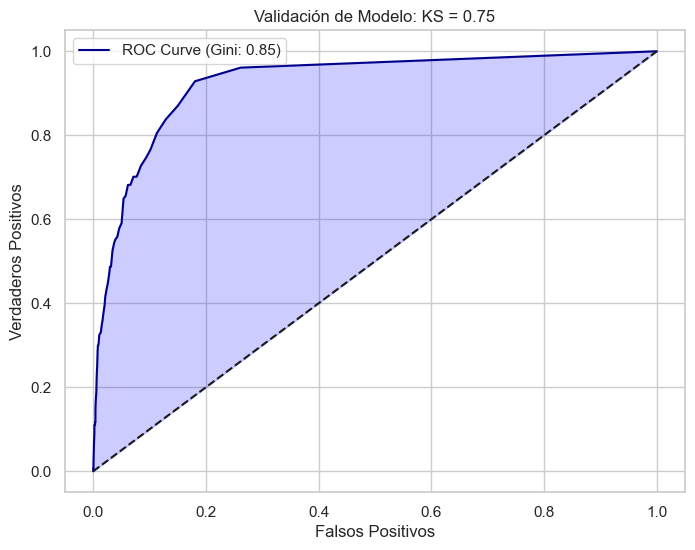

In [32]:
probs = model_weighted.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, probs)

# Métricas
auc_val = roc_auc_score(y_test, probs)
gini_val = 2 * auc_val - 1
ks_val = max(tpr - fpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (Gini: {gini_val:.2f})', color='darkblue')
plt.plot([0, 1], [0, 1], 'k--')
plt.fill_between(fpr, tpr, fpr, alpha=0.2, color='blue')
plt.title(f'Validación de Modelo: KS = {ks_val:.2f}')
plt.xlabel('Falsos Positivos')
plt.ylabel('Verdaderos Positivos')
plt.legend()
plt.show()

## Módulo 3: Impacto en el Negocio (Pérdida Esperada)
La fórmula reina en Banca:
$$EL = PD \times LGD \times EAD$$



Donde:
* **PD (Probabilidad de Incumplimiento):** Salida del modelo de ML.
* **LGD (Loss Given Default):** Lo que no se recupera (usaremos 45%).
* **EAD (Exposure at Default):** Saldo del crédito.

In [36]:
LGD = 0.45
df_test_final = X_test.copy()
df_test_final['PD'] = probs
df_test_final['EL'] = df_test_final['PD'] * LGD * df_test_final['monto_credito']

# Resumen de Cartera
total_reserva = df_test_final['EL'].sum()
print(f"Exposición Total Evaluada: ${df_test_final['monto_credito'].sum():,.2f}")
print(f"Reservas Preventivas a Constituir: ${total_reserva:,.2f}")

# Segmentación por riesgo
df_test_final['Rating'] = pd.cut(df_test_final['PD'], bins=[0, 0.05, 0.20, 1], labels=['Bajo', 'Medio', 'Alto'])
print("\nDistribución de Reservas por Rating:")
print(df_test_final.groupby('Rating')['EL'].sum())

Exposición Total Evaluada: $284,468,546.80
Reservas Preventivas a Constituir: $3,571,808.24

Distribución de Reservas por Rating:
Rating
Bajo     4.250924e+05
Medio    1.089846e+06
Alto     2.056870e+06
Name: EL, dtype: float64


C:\Users\eliut\AppData\Local\Temp\ipykernel_3608\3399960310.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_test_final.groupby('Rating')['EL'].sum())


### Check-list para la entrevista en Banregio:
1. **Interpretabilidad:** Menciona que los modelos de ML deben ser explicables (SHAP o Feature Importance).
2. **Regulación:** Menciona que conoces la importancia de las Reservas Preventivas para la estabilidad del banco.
3. **Estabilidad:** Habla sobre el monitoreo de modelos (PSI - Population Stability Index) para evitar que el modelo se degrade con el tiempo.

# Módulo SQL: Inteligencia de Datos para Riesgo de Crédito
En esta sección simularemos un entorno de base de datos bancaria para practicar:
1. **Análisis de Cohortes (Vintage Analysis):** Para ver cómo madura la mora según el mes de colocación.
2. **Window Functions:** Para calcular promedios móviles y comportamiento histórico por cliente.
3. **Optimización:** Uso de CTEs (Common Table Expressions) y filtrado eficiente.

In [37]:
import sqlite3
import pandas as pd
import numpy as np

# Creamos una base de datos en memoria para practicar
conn = sqlite3.connect(':memory:')

# Creamos una tabla de 'Creditos' y una de 'Pagos'
conn.execute('''
CREATE TABLE creditos (
    id_credito INTEGER PRIMARY KEY,
    fecha_apertura DATE,
    cliente_id INTEGER,
    monto_otorgado REAL
)
''')

conn.execute('''
CREATE TABLE pagos (
    id_pago INTEGER PRIMARY KEY,
    id_credito INTEGER,
    fecha_pago DATE,
    monto_pagado REAL,
    dias_atraso INTEGER
)
''')

# Insertamos datos sintéticos
creditos_data = [
    (1, '2025-01-15', 101, 50000),
    (2, '2025-01-20', 102, 30000),
    (3, '2025-02-10', 103, 45000),
    (4, '2025-02-25', 104, 60000)
]
conn.executemany('INSERT INTO creditos VALUES (?,?,?,?)', creditos_data)

# Corregido: Cada id_pago ahora es único
pagos_data = [
    (1, 1, '2025-02-15', 2000, 0), 
    (2, 1, '2025-03-15', 2000, 5), 
    (3, 1, '2025-04-15', 2000, 32),
    (4, 2, '2025-02-20', 1500, 0), # Cambiado id_pago de 2 a 4
    (5, 2, '2025-03-20', 1500, 0),
    (6, 2, '2025-04-20', 1500, 0), # Cambiado id_pago de 5 a 6
    (7, 3, '2025-03-10', 1800, 0), # Cambiado id_pago de 6 a 7
    (8, 3, '2025-04-10', 1800, 15) # Cambiado id_pago de 7 a 8
]
conn.executemany('INSERT INTO pagos VALUES (?,?,?,?,?)', pagos_data)

print("Entorno SQL configurado correctamente.")

Entorno SQL configurado correctamente.


## 1. Análisis de Cohortes (Vintage Analysis)
El análisis de "cosechas" es vital. Queremos saber: "De los créditos otorgados en Enero, ¿qué porcentaje está en mora de más de 30 días a los 3 meses de vida?".

In [38]:
query_cohortes = '''
WITH Cosechas AS (
    SELECT 
        strftime('%Y-%m', fecha_apertura) AS mes_cosecha,
        id_credito,
        monto_otorgado
    FROM creditos
),
Mora AS (
    SELECT 
        p.id_credito,
        p.fecha_pago,
        p.dias_atraso,
        -- Calculamos los meses transcurridos desde la apertura
        ((strftime('%Y', p.fecha_pago) - strftime('%Y', c.fecha_apertura)) * 12) +
        (strftime('%m', p.fecha_pago) - strftime('%m', c.fecha_apertura)) AS meses_de_vida
    FROM pagos p
    JOIN creditos c ON p.id_credito = c.id_credito
)
SELECT 
    c.mes_cosecha,
    m.meses_de_vida,
    COUNT(DISTINCT c.id_credito) AS num_creditos,
    SUM(CASE WHEN m.dias_atraso > 30 THEN 1 ELSE 0 END) AS creditos_en_mora,
    ROUND(CAST(SUM(CASE WHEN m.dias_atraso > 30 THEN 1 ELSE 0 END) AS REAL) / COUNT(DISTINCT c.id_credito) * 100, 2) AS tasa_mora_pct
FROM Cosechas c
LEFT JOIN Mora m ON c.id_credito = m.id_credito
GROUP BY 1, 2
ORDER BY 1, 2;
'''

pd.read_sql_query(query_cohortes, conn)

,mes_cosecha,meses_de_vida,num_creditos,creditos_en_mora,tasa_mora_pct
0,2025-01,1.0,2,0,0.0
1,2025-01,2.0,2,0,0.0
2,2025-01,3.0,2,1,50.0
3,2025-02,NaN,1,0,0.0
4,2025-02,1.0,1,0,0.0
5,2025-02,2.0,1,0,0.0


## 2. Ventanas de Tiempo (Window Functions)
Las funciones de ventana nos permiten mirar hacia atrás en el historial de un cliente sin colapsar las filas. 
**Escenario:** Necesitamos calcular el "Atraso Máximo" que ha tenido un cliente en los últimos 3 pagos para usarlo como variable en el modelo de comportamiento.

In [39]:
query_ventanas = '''
SELECT 
    id_credito,
    fecha_pago,
    dias_atraso,
    -- Máximo atraso histórico hasta la fecha actual del pago
    MAX(dias_atraso) OVER (PARTITION BY id_credito ORDER BY fecha_pago) AS max_atraso_historico,
    -- Promedio de atraso de los últimos 2 pagos (ventana móvil)
    AVG(dias_atraso) OVER (PARTITION BY id_credito ORDER BY fecha_pago ROWS BETWEEN 1 PRECEDING AND CURRENT ROW) AS avg_atraso_reciente
FROM pagos
ORDER BY id_credito, fecha_pago;
'''

pd.read_sql_query(query_ventanas, conn)

,id_credito,fecha_pago,dias_atraso,max_atraso_historico,avg_atraso_reciente
0,1,2025-02-15,0,0,0.0
1,1,2025-03-15,5,5,2.5
2,1,2025-04-15,32,32,18.5
3,2,2025-02-20,0,0,0.0
4,2,2025-03-20,0,0,0.0
5,2,2025-04-20,0,0,0.0
6,3,2025-03-10,0,0,0.0
7,3,2025-04-10,15,15,7.5


## 3. Optimización en Ambientes de Producción
En un banco con millones de filas, una mala consulta puede tirar el servidor.

### Reglas de Oro:
1. **Filtrado Temprano (SARGability):** Usa `WHERE` antes de los `JOINs` siempre que sea posible. Evita funciones en las columnas del `WHERE` (ej. usar `fecha >= '2025-01-01'` en lugar de `YEAR(fecha) = 2025`).
2. **Uso de CTEs vs Subconsultas:** Las CTEs (`WITH...`) hacen el código más legible y permiten al optimizador de consultas estructurar mejor el plan de ejecución.
3. **Índices:** Asegúrate de que las columnas usadas en los `JOIN` (`id_credito`, `cliente_id`) y filtros frecuentes (`fecha_apertura`) tengan índices.

**Ejemplo de optimización:**
En lugar de traer todos los pagos y luego filtrar, filtramos la tabla de pagos antes del JOIN para reducir el volumen de datos en memoria.

In [40]:
query_optimizado = '''
-- Definimos universos pequeños primero
WITH pagos_recientes AS (
    SELECT id_credito, dias_atraso
    FROM pagos
    WHERE fecha_pago >= '2025-03-01' -- Filtro temprano
)
SELECT 
    c.id_credito,
    c.monto_otorgado,
    pr.dias_atraso
FROM creditos c
INNER JOIN pagos_recientes pr ON c.id_credito = pr.id_credito
WHERE c.monto_otorgado > 10000;
'''

pd.read_sql_query(query_optimizado, conn)

,id_credito,monto_otorgado,dias_atraso
0,1,50000.0,5
1,1,50000.0,32
2,2,30000.0,0
3,2,30000.0,0
4,3,45000.0,0
5,3,45000.0,15


### ¿Qué responder si te preguntan por SQL?
* **"¿Cómo manejas nulos?"**: "En riesgo, un nulo en atraso suele tratarse como 0, pero siempre verifico si es un nulo por falta de información o por ser un cliente nuevo (Cold Start)".
* **"¿Cómo aseguras la calidad?"**: "Uso `DISTINCT` con cuidado para no duplicar saldos y siempre valido los totales contra el balance contable del área".
* **"¿Por qué usar Window Functions?"**: "Porque permiten capturar la **tendencia** del cliente (¿su mora va subiendo o bajando?), lo cual es mucho más predictivo que una foto estática".

# Módulo: Backtesting, Estabilidad (PSI) y Documentación
Un modelo en producción es un organismo vivo. Como Coordinador, tu responsabilidad es asegurar que el modelo siga siendo válido meses después de su implementación.

1.  **Backtesting:** ¿Qué tan bien predijo el modelo en datos que no vio durante el entrenamiento (Out-of-Time)?
2.  **PSI (Population Stability Index):** ¿Ha cambiado la población que solicita crédito hoy respecto a la que usamos para entrenar?
3.  **Documentación:** El puente entre el código y el comité de riesgos/reguladores.

## 1. Backtesting (Out-of-Time - OOT)
En riesgos, no basta con `train_test_split` aleatorio. Debemos probar el modelo con un mes completo que sea posterior al entrenamiento. Esto simula la vida real.

**Métrica clave:** Degradación del Gini. Si el Gini en entrenamiento es 0.70 y en el OOT es 0.40, el modelo no es robusto.

In [47]:
# Simulamos un dataset de "Un mes después" (Out-of-Time)
np.random.seed(99)
data_oot = {
    'ingreso_mensual': np.random.normal(24000, 8500, 2000), # Ligera caída en ingresos
    'dti': np.random.uniform(0.15, 0.75, 2000),            # Mayor endeudamiento
    'score_buro': np.random.normal(630, 70, 2000),         # Peor score promedio
    'antiguedad_laboral': np.random.uniform(0, 15, 2000),
    'monto_credito': np.random.uniform(5000, 120000, 2000)
}
df_oot = pd.DataFrame(data_oot)

# Variable objetivo real del OOT (simulada)
#logit_oot = (0.007 * (680 - df_oot['score_buro']) + 3.5 * df_oot['dti'] - 0.0001 * df_oot['ingreso_mensual'])
#df_oot['target'] = (1 / (1 + np.exp(-logit_oot)) > 0.80).astype(int)

# Mismo logit
logit_oot = (0.007 * (680 - df_oot['score_buro']) + 3.5 * df_oot['dti'] - 0.0001 * df_oot['ingreso_mensual'])

# Añadimos el ruido del mundo real
ruido_oot = np.random.normal(0, 0.15, 2000) 
prob_oot_real = np.clip((1 / (1 + np.exp(-logit_oot))) + ruido_oot, 0, 1)

# Aplicamos el umbral
df_oot['target'] = (prob_oot_real > 0.80).astype(int)

# Evaluación del modelo previo en los nuevos datos
probs_oot = model_weighted.predict_proba(df_oot.drop('target', axis=1))[:, 1]
gini_oot = 2 * roc_auc_score(df_oot['target'], probs_oot) - 1

print(f"Gini en Validación (Test): {gini_val:.4f}")
print(f"Gini en Backtesting (OOT): {gini_oot:.4f}")
print(f"Degradación: {((gini_val - gini_oot) / gini_val)*100:.2f}%")

Gini en Validación (Test): 0.8500
Gini en Backtesting (OOT): 0.8362
Degradación: 1.63%


## 2. Population Stability Index (PSI)
El PSI mide cuánto ha cambiado la distribución de una variable o del Score final.

**Fórmula:** $PSI = \sum (Actual\% - Expected\%) \times \ln(Actual\% / Expected\%)$

**Interpretación:**
* **PSI < 0.10:** Sin cambios significativos (Estable).
* **0.10 < PSI < 0.25:** Cambio moderado (Requiere revisión).
* **PSI > 0.25:** Cambio significativo (El modelo debe recalibrarse o detenerse).

### Implementación del PSI (Population Stability Index)
---
Esta es la implementación de la fórmula estándar de la industria bancaria para medir el **Model Drift**:

$$PSI = \sum_{i=1}^{n} \left( Actual\_i - Expected\_i \right) \times \ln \left( \frac{Actual\_i}{Expected\_i} \right)$$

**¿Cómo funciona la penalización?**
* **Sensibilidad:** La ecuación penaliza fuertemente a los grupos donde la proporción de clientes cambió drásticamente entre el entrenamiento (*Expected*) y la producción (*Actual*).
* **Cero Desviación:** Si un segmento antes concentraba al **10%** de los clientes y actualmente mantiene ese **10%**, esa parte de la suma es $0 \times \ln(1) = 0$. 
* **Resultado:** Si todos los grupos se mantienen idénticos, tu **PSI es 0**. A mayor cambio en la distribución, mayor será el valor del índice.

In [48]:
def calculate_psi(expected, actual, buckets=10):
    # Crear los buckets basados en los deciles de la población esperada (entrenamiento)
    breakpoints = np.percentile(expected, np.arange(0, 100 + 100/buckets, 100/buckets))
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    
    expected_percents = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_percents = np.histogram(actual, bins=breakpoints)[0] / len(actual)
    
    # Evitar ceros para el logaritmo
    actual_percents = np.where(actual_percents == 0, 0.0001, actual_percents)
    expected_percents = np.where(expected_percents == 0, 0.0001, expected_percents)
    
    psi_value = np.sum((actual_percents - expected_percents) * np.log(actual_percents / expected_percents))
    return psi_value

# PSI del Score Final
psi_score = calculate_psi(probs, probs_oot)
print(f"PSI del Modelo: {psi_score:.4f}")

if psi_score < 0.1: print("Estado: ESTABLE")
elif psi_score < 0.25: print("Estado: ADVERTENCIA - Monitorear de cerca")
else: print("Estado: ACCIÓN REQUERIDA - Recalibrar modelo")

PSI del Modelo: 0.0611
Estado: ESTABLE


## 3. Documentación Profesional (Metodología)
Para Bel Banco, la documentación debe permitir que un tercero (auditor o regulador) replique tu trabajo. Un documento de "Metodología de Riesgo" debe incluir:

### Estructura sugerida:
1.  **Objetivo del Modelo:** (Ej: Predecir Probabilidad de Default a 12 meses para Tarjeta de Crédito).
2.  **Definición de Target:** (Ej: 90 días de atraso o más).
3.  **Selección de Variables:** Explicar por qué se eliminaron variables (Multicolinealidad, falta de datos, variables no éticas).
4.  **Algoritmo y Parámetros:** Detallar el uso de XGBoost, los hiperparámetros y el tratamiento de desbalanceo.
5.  **Métricas de Desempeño:** Mostrar el Gini, KS y la Matriz de Confusión.
6.  **Plan de Monitoreo:** Frecuencia con la que calcularás el PSI y el Backtesting (ej. Mensual).

In [43]:
# Una tabla de importancia de variables es vital para la documentación
feature_importance = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': model_weighted.feature_importances_
}).sort_values(by='Importancia', ascending=False)

# Esto se copia directamente al anexo técnico del documento de metodología
print("Anexo Técnico: Importancia de Variables para Documentación")
print(feature_importance)

Anexo Técnico: Importancia de Variables para Documentación
             Variable  Importancia
0     ingreso_mensual     0.465268
1                 dti     0.242161
2          score_buro     0.162012
4       monto_credito     0.069411
3  antiguedad_laboral     0.061149


### ¿Cómo hablar de esto en la entrevista?

* **Sobre Backtesting:** "No solo confío en el Gini de entrenamiento; implemento un pipeline de Backtesting Out-of-Time para asegurar que el modelo sea resiliente a ciclos económicos".
* **Sobre PSI:** "Monitoreo el PSI mensualmente. Si detecto un valor arriba de 0.10 en variables críticas como el DTI, analizo si es un cambio en el mercado o un error en la captura de datos antes de proponer una recalibración".
* **Sobre Documentación:** "Veo la documentación como un activo del banco. Mis procesos incluyen un 'Manual Metodológico' que garantiza la continuidad del área y facilita las auditorías de la CNBV".

## Módulo: Calificación Paramétrica y Scorecards
El objetivo es transformar la Probabilidad de Incumplimiento ($PD$) en un **Score** (ej. de 0 a 1000 puntos). Esto facilita la toma de decisiones rápida en la originación de crédito.

In [44]:
import numpy as np

# Supongamos que tenemos las PDs de nuestro modelo anterior
# Vamos a escalar estas probabilidades a un puntaje de 0 a 1000
# Donde 1000 es el cliente más seguro y 0 el de mayor riesgo

def scale_to_score(pd, target_score=600, target_odds=50, pdo=20):
    """
    pd: Probabilidad de Incumplimiento
    target_score: Score de referencia
    target_odds: Odds en el score de referencia (Prob de NO Default / Prob de Default)
    pdo: Points to Double the Odds (puntos para duplicar la confianza)
    """
    factor = pdo / np.log(2)
    offset = target_score - (factor * np.log(target_odds))
    
    # Calculamos los odds (prob de pagar / prob de no pagar)
    # Evitamos división por cero o logaritmo de cero
    pd = np.clip(pd, 0.0001, 0.9999)
    odds = (1 - pd) / pd
    
    score = offset + (factor * np.log(odds))
    return score

# Aplicamos el escalamiento a nuestra cartera
df_test_final['Score'] = df_test_final['PD'].apply(scale_to_score)

print("Ejemplo de Calificación Paramétrica (Escalamiento):")
print(df_test_final[['PD', 'Score']].head())

Ejemplo de Calificación Paramétrica (Escalamiento):
         PD       Score
13885  0.09  553.880269
8763   0.00  752.874238
10436  0.00  752.874238
8683   0.00  752.874238
7220   0.00  752.874238


### 3. Calificación por Letras (Ratings)
---
En la práctica bancaria, no se le dice al comité **"este cliente tiene 742 puntos"**, sino que se le asigna una **calificación paramétrica**.

In [49]:
# Definición de la escala paramétrica (Ejemplo tipo Banregio/CNBV)
def asignar_rating(score):
    if score >= 800: return 'A1 - Excelente'
    elif score >= 700: return 'A2 - Muy Bueno'
    elif score >= 600: return 'B1 - Bueno'
    elif score >= 500: return 'B2 - Aceptable'
    elif score >= 400: return 'C1 - Riesgo Moderado'
    else: return 'D/E - Riesgo Crítico / Rechazo'

df_test_final['Calificacion_Parametrica'] = df_test_final['Score'].apply(asignar_rating)

# Ver distribución de la cartera por calificación
distribucion = df_test_final['Calificacion_Parametrica'].value_counts(normalize=True).sort_index() * 100
print("Distribución de la Cartera por Calificación Paramétrica (%):")
print(distribucion)

Distribución de la Cartera por Calificación Paramétrica (%):
Calificacion_Parametrica
A2 - Muy Bueno          71.444444
B1 - Bueno               7.933333
B2 - Aceptable          19.200000
C1 - Riesgo Moderado     1.422222
Name: proportion, dtype: float64


### 4. Tips  sobre Calificación Paramétrica
---
**Por qué usar esto en lugar de solo el modelo de Machine Learning?:**

* **Interpretabilidad:** "La calificación paramétrica permite que el área comercial entienda por qué se aprobó o rechazó un crédito. Es más fácil explicar que un cliente 'cayó de **B1 a C1**' por su nivel de endeudamiento que hablar de un cambio en el gradiente del XGBoost".
* **Consistencia Regulatoria:** "Las metodologías de la **CNBV** suelen pedir calificaciones discretas para el cálculo de reservas. Un esquema paramétrico asegura que clientes con perfiles similares reciban el mismo tratamiento".
* **Estrategias de Precio:** "Podemos asignar tasas de interés diferenciadas basadas en la calificación. Un cliente '**A1**' recibe una tasa preferencial, mientras que un '**B2**' paga una prima de riesgo más alta".

### 1. SHAP (Interpretación basada en Teoría de Juegos)
---
**SHAP** responde a la pregunta: *¿Exactamente cuántos puntos sumó o restó cada variable a la predicción final de este cliente específico?*

* **Concepto clave:** Se basa en los **"Valores de Shapley"** de la teoría de juegos. Imagina que las variables (Ingreso, Edad, Score de Buró) son "jugadores" en un equipo. SHAP calcula el **aporte marginal** de cada jugador al resultado final (la Probabilidad de Default).
* **Por qué es mejor:** A diferencia de la "Importancia de Variables" tradicional, SHAP te da la **dirección** (si la variable sube o baja el riesgo) y la **magnitud** de manera individualizada.

C:\Users\eliut\AppData\Local\Temp\ipykernel_3608\1397336952.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)
C:\Users\eliut\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
C:\Users\eliut\anaconda3\Lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


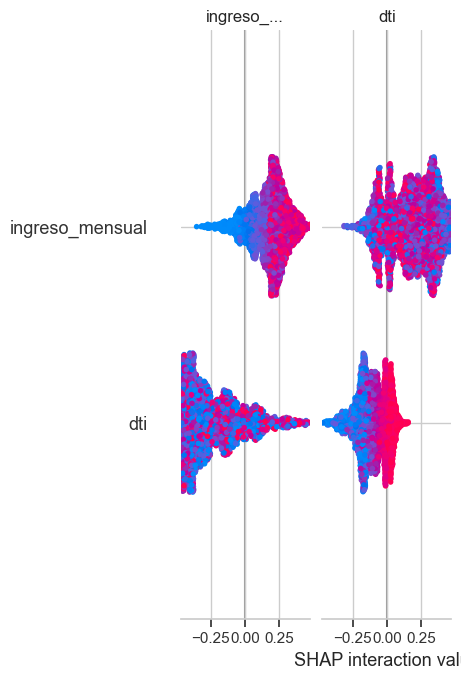

TypeError: In v0.20, force plot now requires the base value as the first parameter! Try shap.plots.force(explainer.expected_value, shap_values) or for multi-output models try shap.plots.force(explainer.expected_value[0], shap_values[..., 0]).

In [46]:
import shap

# 1. Creamos el "Explainer" usando nuestro modelo ya entrenado
explainer = shap.TreeExplainer(model_weighted)

# 2. Calculamos los valores SHAP para el set de prueba
shap_values = explainer.shap_values(X_test)

# 3. Visualización Global: ¿Qué variables mueven más la aguja?
shap.summary_plot(shap_values, X_test)

# 4. Visualización Local: Explicar UN solo cliente (ej. el primero)
# Este es el que le mostrarías a un auditor
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], X_test.iloc[0,:])

### 2. Restricciones de Monotonicidad (Monotonicity Constraints)
---
Este es el **"seguro de vida"** de tus modelos de Machine Learning en banca. Evita que el modelo tome decisiones que desafíen la lógica económica.

* **El problema:** A veces, debido al ruido en los datos, un modelo de Gradient Boosting podría decidir que *"si un cliente gana `$50,000` tiene menos riesgo que uno que gana `$60,000`"*. Esto es indefendible ante un comité.
* **La solución:** Forzamos al algoritmo a que la relación sea siempre **creciente** o siempre **decreciente**.

**Configuración típica de parámetros:**
* **1:** Relación creciente (A mayor X, mayor Riesgo). *Ejemplo: DTI (Deuda/Ingreso).*
* **-1:** Relación decreciente (A mayor X, menor Riesgo). *Ejemplo: Ingreso Mensual.*
* **0:** Sin restricción.


In [ ]:

# Import XGBoost library after installation
import xgboost as xgb

# Definimos las restricciones para nuestras variables
# 1: Incremental, -1: Decremental, 0: Sin restricción
constraints = {
    'ingreso_mensual': -1,   # A más ingreso, menos default
    'dti': 1,                # A más deuda, más default
    'score_buro': -1,        # A más score, menos default
    'antiguedad_laboral': -1 # A más antigüedad, menos default
}

# Convertimos el diccionario a una tupla en el orden de las columnas de X
params_constraints = tuple(constraints.get(col, 0) for col in X_train.columns)

# Entrenamos el modelo con la restricción
model_monotone = xgb.XGBClassifier(
    monotone_constraints = params_constraints,
    n_estimators=100,
    learning_rate=0.1
)
model_monotone.fit(X_train, y_train)

In [ ]:
# 1. Crear el explainer
explainer_rf = shap.TreeExplainer(model_weighted)

# 2. Generar el objeto Explanation (usando la llamada directa, no .shap_values)
# Esto devuelve un objeto con .values, .base_values y .data integrados
shap_values_obj = explainer_rf(X_test)

# 3. Validar si es multi-clase (Random Forest siempre lo es para SHAP)
# Para la clase positiva (default = 1), seleccionamos el índice [:, :, 1]
# Esto extrae: [todas las filas, todas las columnas, clase 1]
shap_pos_class = shap_values_obj[:, :, 1]

# 4. Graficar (usando la nueva API de plots que es más robusta)
print("Summary Plot - Clase Positiva:")
shap.plots.beeswarm(shap_pos_class)

# 5. Waterfall Plot para un cliente específico
print(f"\nWaterfall SHAP — Cliente #{cliente_idx}:")
shap.plots.waterfall(shap_pos_class[cliente_idx])